# Problem 1 — CNN: Fruits-360 Classification

**Goal:** Build a Convolutional Neural Network to classify fruit images from the Fruits-360 dataset.
**Target:** Average accuracy > 80%, precision & recall > 70%.

**Notebook outline:**
1. Environment setup & seeds
2. Data download & exploration
3. Preprocessing pipeline
4. Baseline CNN + systematic architecture experiments
5. Data augmentation study
6. Overfitting analysis & regularisation
7. Transfer learning (MobileNetV2)
8. Evaluation: confusion matrix, per-class metrics, feature maps, best/worst predictions

## 1. Environment Setup

Fix all random seeds so results are reproducible across runs.
We also configure TensorFlow to avoid non-determinism from GPU thread scheduling.

In [3]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, accuracy_score
)
from pathlib import Path
import time

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

class EpochTimer(keras.callbacks.Callback):
    """Prints epoch start, elapsed time, and key metrics (works with verbose=0)."""
    def on_epoch_begin(self, epoch, logs=None):
        self._t0 = time.time()
        total = self.params.get('epochs', '?')
        print(f'  Epoch {epoch + 1}/{total} starting...', flush=True)
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        elapsed = time.time() - self._t0
        metrics = ' | '.join(
            f'{k}={logs[k]:.4f}' for k in ('loss', 'accuracy', 'val_loss', 'val_accuracy')
            if k in logs
        )
        print(f'  Epoch {epoch + 1} done — {elapsed:.1f}s  {metrics}', flush=True)

# Smoke-test config: use a tiny slice of data + very few epochs to verify the
# end-to-end workflow. Bump SUBSET_FRACTION to 1.0 and increase epoch counts
# for the real run.
SUBSET_FRACTION = 0.15  # 15% — small enough to be fast, large enough for BN stats to stabilize

# Directories
FIGURES_DIR = Path('../figures')
MODELS_DIR  = Path('../models')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

2026-05-23 18:06:32.858673: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-23 18:06:33.679144: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-05-23 18:06:33.679228: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-05-23 18:06:33.783736: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-23 18:06:36.061502: W tensorflow/stream_executor/platform/de

TensorFlow: 2.10.0
GPU available: []


2026-05-23 18:06:38.912708: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-05-23 18:06:38.914057: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2026-05-23 18:06:38.914328: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (67021276f4f9): /proc/driver/nvidia/version does not exist


## 2. Data Download

We use `kagglehub` to download the Fruits-360 dataset. The returned path points to the cached directory containing `train/` and `test/` subfolders, each organised by class name — the standard `ImageDataGenerator` / `image_dataset_from_directory` format.

In [6]:
import kagglehub

path_fruits = kagglehub.dataset_download('moltean/fruits')
print('Dataset root:', path_fruits)

100%|██████████| 5.95G/5.95G [14:04<00:00, 7.56MB/s]  

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/moltean/fruits/versions/93


In [7]:
# Locate the actual train/test split — kagglehub may nest inside a versioned folder
def find_split_root(base):
    """Walk down until we find a directory that contains a 'Training' or 'train' sub-dir."""
    base = Path(base)
    for root, dirs, _ in os.walk(base):
        root = Path(root)
        lower = [d.lower() for d in dirs]
        if 'training' in lower or 'train' in lower:
            return root
    return base

dataset_root = find_split_root(path_fruits)
print('Using dataset root:', dataset_root)

# Resolve train/test dirs (handle both naming conventions)
def resolve_dir(root, candidates):
    for c in candidates:
        p = root / c
        if p.exists():
            return p
    raise FileNotFoundError(f'None of {candidates} found under {root}')

TRAIN_DIR = resolve_dir(dataset_root, ['Training', 'train', 'Train'])
TEST_DIR  = resolve_dir(dataset_root, ['Test', 'test', 'Testing'])
print('Train dir:', TRAIN_DIR)
print('Test dir: ', TEST_DIR)

Using dataset root: /root/.cache/kagglehub/datasets/moltean/fruits/versions/93/fruits-360_original-size/fruits-360-original-size
Train dir: /root/.cache/kagglehub/datasets/moltean/fruits/versions/93/fruits-360_original-size/fruits-360-original-size/Training
Test dir:  /root/.cache/kagglehub/datasets/moltean/fruits/versions/93/fruits-360_original-size/fruits-360-original-size/Test


## 3. Data Exploration

Before training we need to understand:
- How many classes there are and whether they are balanced (class imbalance affects loss and metrics).
- What the images look like (helps choose preprocessing steps).

In [19]:
# Count samples per class in the training set
class_names = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(class_names)
class2idx = {c: i for i, c in enumerate(class_names)}

counts = {c: len(list((TRAIN_DIR / c).glob('*.jpg'))) for c in class_names}
counts_series = pd.Series(counts).sort_values(ascending=False)

print(f'Number of classes : {NUM_CLASSES}')
print(f'Total train images: {counts_series.sum()}')
print(f'Min samples/class : {counts_series.min()}')
print(f'Max samples/class : {counts_series.max()}')
print(f'Mean samples/class: {counts_series.mean():.1f}')

Number of classes : 144
Total train images: 51345
Min samples/class : 96
Max samples/class : 648
Mean samples/class: 356.6


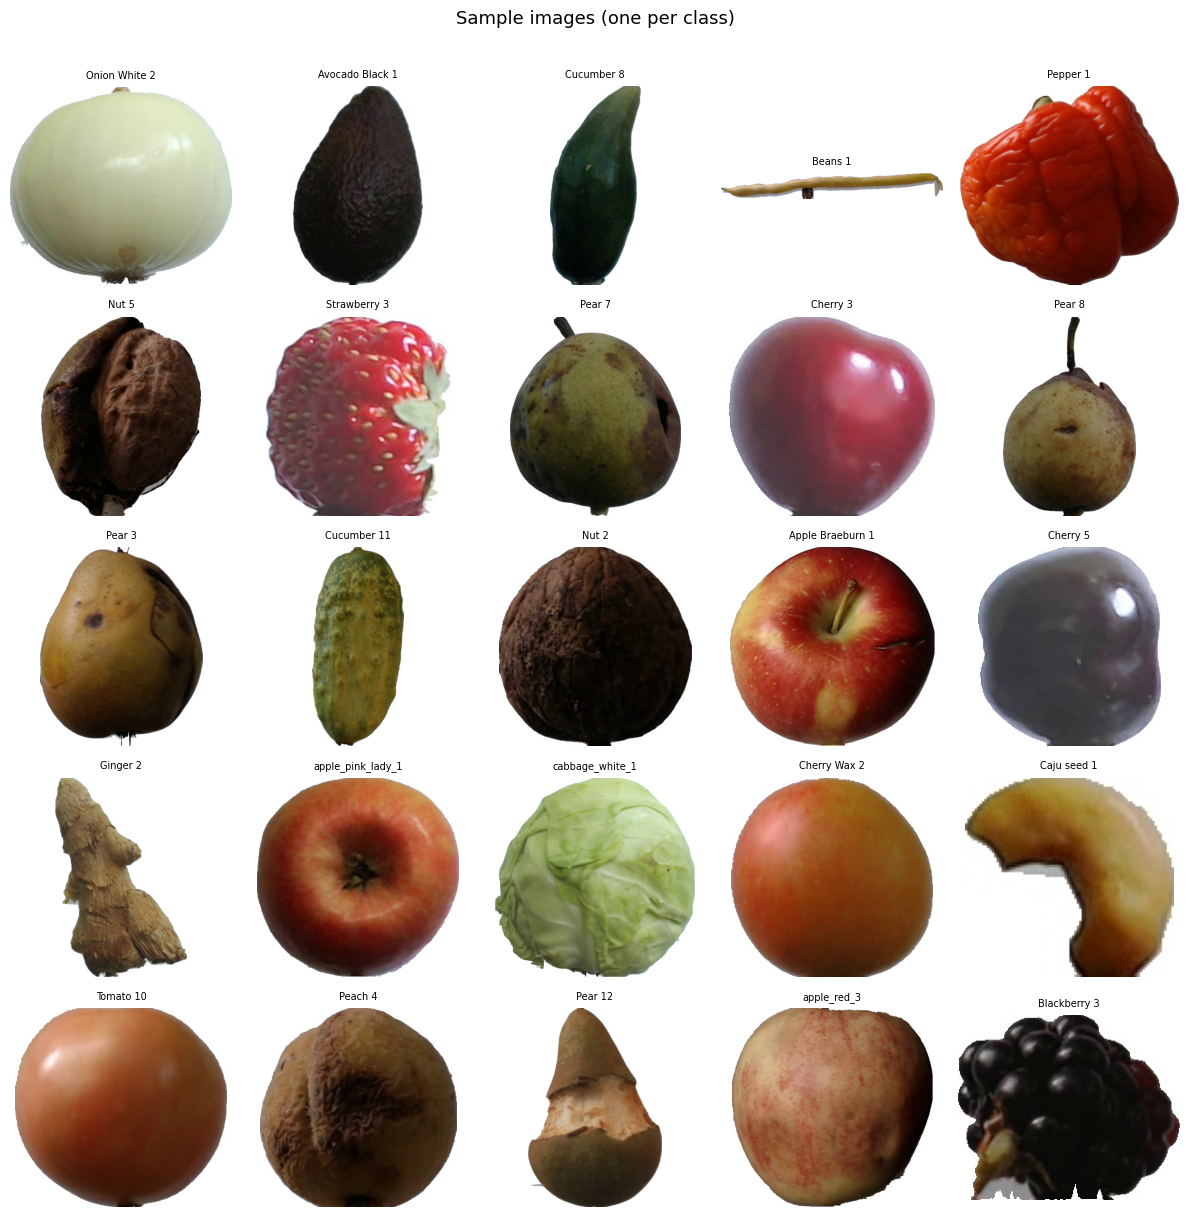

Sample image size (W×H): (221, 139)
Mode: RGB


In [24]:
from PIL import Image

# Display a 5x5 grid of random sample images
sample_classes = random.sample(class_names, min(25, NUM_CLASSES))
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
for ax, cls in zip(axes.flat, sample_classes):
    img_path = random.choice(list((TRAIN_DIR / cls).glob('*.jpg')))
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(cls[:20], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample images (one per class)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_02_sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# Check image sizes
sample_img = Image.open(next((TRAIN_DIR / class_names[0]).glob('*.jpg')))
print('Sample image size (W×H):', sample_img.size)
print('Mode:', sample_img.mode)

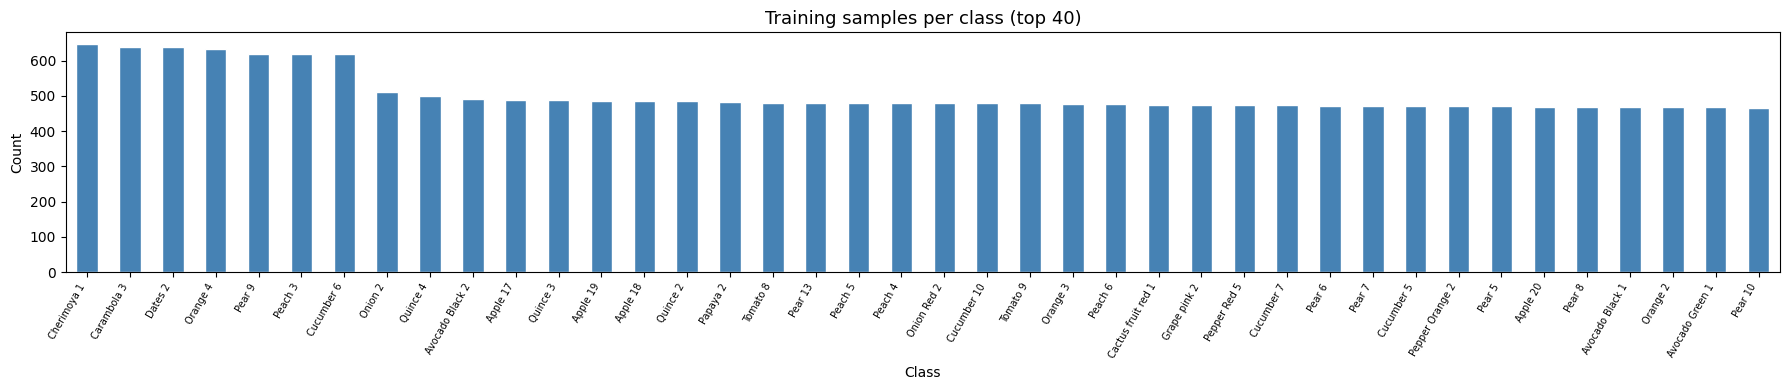

In [22]:
# Class distribution bar chart — first 40 classes for readability
fig, ax = plt.subplots(figsize=(18, 4))
counts_series.head(40).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Training samples per class (top 40)', fontsize=13)
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.xticks(rotation=60, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_01_class_distribution.png', dpi=150)
plt.show()

## 4. Preprocessing Pipeline

**Steps and justifications:**

| Step | Justification |
|---|---|
| Resize to 64×64 | Fruits-360 images are already 100×100. Reducing to 64×64 cuts memory and compute, while keeping enough spatial detail for fruit classification. |
| Rescale to [0, 1] | Neural networks converge faster when inputs are small floats. Dividing by 255 maps uint8 pixel values to [0,1]. |
| Train/val split 80/20 | Gives a large enough validation set to estimate generalisation without wasting training data. |
| Shuffle train set | Prevents the model from learning order-dependent patterns in mini-batches. |

In [25]:
IMG_SIZE   = (64, 64)
BATCH_SIZE = 64

# Load training set and split off 20% for validation
train_ds_full = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset='training'
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False,
    seed=SEED,
    validation_split=0.2,
    subset='validation'
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

# Subset training only — keep val/test full so we get representative metrics.
# Validation runs are cheap (forward pass only), and a tiny shuffled val set
# from the first alphabetical classes gives misleading 0.0 accuracies.
if SUBSET_FRACTION < 1.0:
    train_ds_full = train_ds_full.take(max(1, round(len(train_ds_full) * SUBSET_FRACTION)))

# Rescale pixels from [0,255] to [0,1] — applied on the fly to save RAM
rescale = layers.Rescaling(1.0 / 255)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_full.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

val_ds   = val_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print('Train batches:', len(train_ds))
print('Val batches  :', len(val_ds))
print('Test batches :', len(test_ds))

Found 51345 files belonging to 144 classes.
Using 41076 files for training.
Found 51345 files belonging to 144 classes.
Using 10269 files for validation.
Found 25526 files belonging to 144 classes.
Train batches: 96
Val batches  : 161
Test batches : 399


## 5. Baseline CNN + Architecture Experiments

We first define a **baseline** CNN, then systematically vary:
- Number of filters
- Stride
- Padding
- Pooling type (Max vs Average)

Each run's validation accuracy is logged in a results table for comparison.

In [ ]:
def build_cnn(
    num_classes,
    filters=(32, 64, 128),
    kernel_size=3,
    strides=1,
    padding='same',
    pool='max',
    dropout_rate=0.0,
    l2_reg=0.0,
    input_shape=(64, 64, 3)
):
    """Configurable CNN builder for systematic experiments."""
    pool_layer = layers.MaxPooling2D if pool == 'max' else layers.AveragePooling2D
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None

    model = keras.Sequential(name='CNN')
    model.add(layers.Input(shape=input_shape))
    for f in filters:
        model.add(layers.Conv2D(f, kernel_size, strides=strides,
                                padding=padding, activation='relu',
                                kernel_regularizer=reg))
        model.add(layers.BatchNormalization())
        model.add(pool_layer(2))
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=reg))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model


def train_model(model, train_ds, val_ds, epochs=15, callbacks=None,
                verbose=1, early_stop=True, patience=3):
    """Compile, fit, and return history. Adds EarlyStopping unless one is already passed."""
    cbs = list(callbacks) if callbacks else []
    if early_stop and not any(isinstance(c, EarlyStopping) for c in cbs):
        cbs.append(EarlyStopping(monitor='val_accuracy', patience=patience,
                                 restore_best_weights=True, verbose=1))
    cbs.append(EpochTimer())
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=cbs,
        verbose=verbose
    )
    return history

In [ ]:
# --- Baseline model ---
baseline = build_cnn(NUM_CLASSES)
baseline.summary()

In [ ]:
# Train baseline
baseline_history = train_model(baseline, train_ds, val_ds, epochs=5)
baseline_val_acc = max(baseline_history.history['val_accuracy'])
print(f'Baseline best val accuracy: {baseline_val_acc:.4f}')

In [ ]:
# --- Systematic experiments (light mode) ---
# Smoke-test grid: 4 lightweight configs × 3 epochs. Expand for the real run.

EXPERIMENT_EPOCHS = 5
results = []

experiments = [
    dict(name='Baseline',           filters=(32,64,128), strides=1, padding='same', pool='max'),
    dict(name='Fewer filters',      filters=(16,32,64),  strides=1, padding='same', pool='max'),
    dict(name='AvgPool',            filters=(32,64,128), strides=1, padding='same', pool='avg'),
    dict(name='Stride=2 (no pool)', filters=(32,64,128), strides=2, padding='same', pool='max'),
]

for i, exp in enumerate(experiments, 1):
    name = exp.pop('name')
    print(f'\n>>> [{i}/{len(experiments)}] Training: {name}', flush=True)
    tf.random.set_seed(SEED)
    m = build_cnn(NUM_CLASSES, **exp)
    h = train_model(m, train_ds, val_ds, epochs=EXPERIMENT_EPOCHS, verbose=0)
    best_val = max(h.history['val_accuracy'])
    results.append({'Experiment': name,
                    'Filters': str(exp['filters']),
                    'Strides': exp['strides'],
                    'Padding': exp['padding'],
                    'Pool': exp['pool'],
                    'Val Accuracy': round(best_val, 4)})
    print(f'  >>> [{name}] best_val_acc={best_val:.4f}', flush=True)

results_df = pd.DataFrame(results).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
print('\n=== Architecture Experiments ===')
print(results_df.to_string(index=False))

## 6. Best Architecture — Full Training + Network Diagram

We pick the configuration with the highest validation accuracy from the grid search and retrain it for more epochs with early stopping.

In [ ]:
# Rebuild best architecture (use the best entry from results_df)
best_config = results[results_df.index[0]]
import ast

# Parse filters string back to tuple
best_filters = tuple(ast.literal_eval(results_df.iloc[0]['Filters']))
best_padding = str(results_df.iloc[0]['Padding'])
best_pool    = str(results_df.iloc[0]['Pool'])
best_strides = int(results_df.iloc[0]['Strides'])  # pandas stores as numpy.int64

tf.random.set_seed(SEED)
best_cnn = build_cnn(
    NUM_CLASSES,
    filters=best_filters,
    strides=best_strides,
    padding=best_padding,
    pool=best_pool,
    dropout_rate=0.4,   # light regularisation for full training
    l2_reg=1e-4
)
best_cnn.summary()

# Network diagram via plot_model (needs pydot + graphviz; falls back gracefully)
_arch_path = FIGURES_DIR / 'cnn_03_architecture.png'
try:
    keras.utils.plot_model(
        best_cnn,
        to_file=str(_arch_path),
        show_shapes=True,
        show_layer_names=True,
        dpi=96
    )
    from IPython.display import Image as IPImage
    display(IPImage(str(_arch_path)))
except (ImportError, OSError) as e:
    print(f'plot_model unavailable ({e}); install pydot + graphviz to enable diagram export.')
    print('Falling back to model.summary() above.')

In [ ]:
# visualkeras layer diagram (alternative visual)
try:
    import visualkeras
    img = visualkeras.layered_view(best_cnn, legend=True,
                                    to_file=str(FIGURES_DIR / 'cnn_03b_visualkeras.png'))
    from IPython.display import Image as IPImage
    IPImage(str(FIGURES_DIR / 'cnn_03b_visualkeras.png'))
except ImportError:
    print('visualkeras not installed; using plot_model diagram only.')

In [ ]:
es = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor='val_accuracy', patience=2, factor=0.5, verbose=1)

best_history = train_model(best_cnn, train_ds, val_ds, epochs=6, callbacks=[es, rlr])
print(f'Best model val accuracy: {max(best_history.history["val_accuracy"]):.4f}')

## 7. Data Augmentation Study

**Why augmentation?** It artificially increases dataset diversity by applying random label-preserving transforms, reducing overfitting especially when data is limited.

We compare training curves **with** and **without** augmentation on the same architecture to isolate the effect.

In [ ]:
# Augmentation layer — applied only during training (Keras handles the train/inference switch)
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),       # ±10% of a full rotation
    layers.RandomZoom(0.1),           # ±10% zoom
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomBrightness(0.1),
], name='augmentation')

# Augmented train dataset
train_aug_ds = train_ds_full.map(
    lambda x, y: (augmentation(rescale(x), training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

# Model WITHOUT augmentation (already trained above as best_cnn; re-train fresh for fair comparison)
tf.random.set_seed(SEED)
m_no_aug = build_cnn(NUM_CLASSES, filters=best_filters, strides=best_strides,
                     padding=best_padding, pool=best_pool, dropout_rate=0.4, l2_reg=1e-4)
hist_no_aug = train_model(m_no_aug, train_ds, val_ds, epochs=5)

# Model WITH augmentation
tf.random.set_seed(SEED)
m_aug = build_cnn(NUM_CLASSES, filters=best_filters, strides=best_strides,
                  padding=best_padding, pool=best_pool, dropout_rate=0.4, l2_reg=1e-4)
hist_aug = train_model(m_aug, train_aug_ds, val_ds, epochs=5)

print('No-aug val acc:', max(hist_no_aug.history['val_accuracy']))
print('With-aug val acc:', max(hist_aug.history['val_accuracy']))

In [ ]:
# Overlay learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for hist, label, color in [
    (hist_no_aug, 'No augmentation', 'steelblue'),
    (hist_aug,    'With augmentation', 'darkorange')
]:
    ax1.plot(hist.history['accuracy'],     linestyle='-',  color=color, label=f'{label} (train)')
    ax1.plot(hist.history['val_accuracy'], linestyle='--', color=color, label=f'{label} (val)')
    ax2.plot(hist.history['loss'],         linestyle='-',  color=color, label=f'{label} (train)')
    ax2.plot(hist.history['val_loss'],     linestyle='--', color=color, label=f'{label} (val)')

ax1.set_title('Accuracy: augmentation vs no augmentation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=7)

ax2.set_title('Loss: augmentation vs no augmentation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_04_augmentation_comparison.png', dpi=150)
plt.show()

## 8. Overfitting Analysis & Regularisation

**How to detect overfitting:** The training accuracy rises while validation accuracy plateaus or falls, and/or training loss decreases while validation loss increases.

**Fixes applied:**
- **Dropout (0.5):** Randomly zeros activations during training, forcing the network to learn redundant representations.
- **L2 weight decay (1e-3):** Penalises large weights, preventing neurons from co-adapting too tightly to training data.
- **Early stopping:** Stops training when validation accuracy stops improving, directly preventing overfit epochs.

In [ ]:
# Deliberately overfit: large model, no regularisation, many epochs
tf.random.set_seed(SEED)
m_overfit = build_cnn(NUM_CLASSES, filters=(128, 256, 512),
                      dropout_rate=0.0, l2_reg=0.0)
hist_overfit = train_model(m_overfit, train_ds, val_ds, epochs=6, early_stop=False)

# Regularised version of the same large model
tf.random.set_seed(SEED)
m_reg = build_cnn(NUM_CLASSES, filters=(128, 256, 512),
                  dropout_rate=0.5, l2_reg=1e-3)
es_reg = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
hist_reg = train_model(m_reg, train_aug_ds, val_ds, epochs=6, callbacks=[es_reg])

print('Overfit model  - best val acc:', max(hist_overfit.history['val_accuracy']))
print('Regularised    - best val acc:', max(hist_reg.history['val_accuracy']))

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for hist, label, color in [
    (hist_overfit, 'No regularisation (overfit)', 'crimson'),
    (hist_reg,     'Dropout + L2 + EarlyStopping', 'green')
]:
    ax1.plot(hist.history['accuracy'],     '-',  color=color, label=f'{label} train')
    ax1.plot(hist.history['val_accuracy'], '--', color=color, label=f'{label} val')
    ax2.plot(hist.history['loss'],         '-',  color=color, label=f'{label} train')
    ax2.plot(hist.history['val_loss'],     '--', color=color, label=f'{label} val')

ax1.set_title('Accuracy: overfit vs regularised')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend(fontsize=8)

ax2.set_title('Loss: overfit vs regularised')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_05_overfitting_analysis.png', dpi=150)
plt.show()

## 9. Transfer Learning — MobileNetV2

**Why transfer learning?** MobileNetV2 was pre-trained on ImageNet (~1.2M images, 1000 classes). Its convolutional layers already encode low-level (edges, textures) and mid-level (shapes, parts) features transferable to fruit images. We freeze the base and only train a custom head, then fine-tune the top layers.

**Input size note:** MobileNetV2 expects at least 32×32; we use 96×96 for better feature resolution.

In [ ]:
TL_IMG_SIZE = (96, 96)
TL_BATCH    = 64

# Reload datasets at 96×96 for transfer learning
def make_tl_ds(directory, subset=None, val_split=None, shuffle=False):
    kwargs = dict(image_size=TL_IMG_SIZE, batch_size=TL_BATCH,
                  label_mode='int', seed=SEED)
    if subset:
        kwargs.update(validation_split=val_split, subset=subset)
    if shuffle:
        kwargs['shuffle'] = True
    ds = keras.utils.image_dataset_from_directory(directory, **kwargs)
    # MobileNetV2 preprocess: scale to [-1, 1]
    preprocess = tf.keras.applications.mobilenet_v2.preprocess_input
    return ds.map(lambda x, y: (preprocess(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

tl_train_ds = make_tl_ds(TRAIN_DIR, subset='training',   val_split=0.2, shuffle=True)
tl_val_ds   = make_tl_ds(TRAIN_DIR, subset='validation', val_split=0.2)
tl_test_ds  = make_tl_ds(TEST_DIR)
# Subset TL training only — keep val/test full for representative metrics.
if SUBSET_FRACTION < 1.0:
    tl_train_ds = tl_train_ds.take(max(1, round(len(tl_train_ds) * SUBSET_FRACTION)))


In [ ]:
# Build MobileNetV2 model — frozen base first
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*TL_IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # freeze all base layers

inputs = keras.Input(shape=(*TL_IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
tl_model = keras.Model(inputs, outputs, name='MobileNetV2_finetune')
tl_model.summary()

# Phase 1: train only the new head
tl_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])
es_tl = EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True, verbose=1)
hist_tl_head = tl_model.fit(tl_train_ds, validation_data=tl_val_ds,
                             epochs=3, callbacks=[es_tl, EpochTimer()], verbose=1)
print('Phase 1 val acc:', max(hist_tl_head.history['val_accuracy']))

In [ ]:
# Phase 2: fine-tune top 40 layers of the base with a small LR
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

tl_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])
es_tl2 = EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True, verbose=1)
hist_tl_ft = tl_model.fit(tl_train_ds, validation_data=tl_val_ds,
                           epochs=4, callbacks=[es_tl2, EpochTimer()], verbose=1)
tl_val_acc = max(hist_tl_ft.history['val_accuracy'])
print('Phase 2 (fine-tune) val acc:', tl_val_acc)

In [ ]:
# Add transfer learning result to the experiments table
results.append({
    'Experiment': 'MobileNetV2 (transfer)',
    'Filters': 'pretrained', 'Strides': '-',
    'Padding': '-', 'Pool': 'GAP',
    'Val Accuracy': round(tl_val_acc, 4)
})
results_df = pd.DataFrame(results).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
print('\n=== Full Experiments Table (including Transfer Learning) ===')
print(results_df.to_string(index=False))

## 10. Save Best Model

We compare the final validation accuracy of our best custom CNN vs MobileNetV2 and save the winner.

In [ ]:
custom_val_acc = max(best_history.history['val_accuracy'])
print(f'Best custom CNN val acc : {custom_val_acc:.4f}')
print(f'MobileNetV2 fine-tune   : {tl_val_acc:.4f}')

if tl_val_acc >= custom_val_acc:
    final_model   = tl_model
    final_test_ds = tl_test_ds
    print('=> Using MobileNetV2 as final model')
else:
    final_model   = best_cnn
    final_test_ds = test_ds
    print('=> Using custom CNN as final model')

final_model.save(str(MODELS_DIR / 'cnn_best.keras'))
print('Model saved to models/cnn_best.keras')

## 11. Evaluation

### 11.1 Overall test accuracy, precision & recall

In [ ]:
# Collect all predictions on the test set
y_true, y_pred_probs = [], []
for x_batch, y_batch in final_test_ds:
    probs = final_model.predict(x_batch, verbose=0)
    y_pred_probs.append(probs)
    y_true.extend(y_batch.numpy())

y_pred_probs = np.vstack(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(y_true)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)

print(f'Test Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'Macro Precision: {prec:.4f}')
print(f'Macro Recall   : {rec:.4f}')
print()
print('Target: accuracy > 80%, precision & recall > 70%')
print(f'  Accuracy OK : {acc > 0.80}')
print(f'  Precision OK: {prec > 0.70}')
print(f'  Recall OK   : {rec > 0.70}')

### 11.2 Confusion Matrix

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(cm, cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0, cbar=True)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title('Confusion Matrix — Test Set', fontsize=13)
plt.xticks(rotation=90, fontsize=5)
plt.yticks(rotation=0,  fontsize=5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_06_confusion_matrix.png', dpi=150)
plt.show()

### 11.3 Per-class metrics

In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names,
                               output_dict=True, zero_division=0)
per_class_df = pd.DataFrame(report).T.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
per_class_df = per_class_df[['precision', 'recall', 'f1-score', 'support']].sort_values('f1-score')

# Show bottom-10 hardest classes
print('Ten hardest classes (lowest F1):')
print(per_class_df.head(10).to_string())

# Plot per-class accuracy bar (top/bottom 20)
per_cls_acc = {cls: (cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0)
               for i, cls in enumerate(class_names)}
acc_series = pd.Series(per_cls_acc).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
acc_series.head(20).plot(kind='barh', ax=axes[0], color='salmon')
axes[0].set_title('20 Lowest Per-class Accuracy')
axes[0].set_xlabel('Accuracy')
acc_series.tail(20).plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('20 Highest Per-class Accuracy')
axes[1].set_xlabel('Accuracy')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_07_per_class_accuracy.png', dpi=150)
plt.show()

### 11.4 Feature Map Visualisation

We build a sub-model that outputs the first convolutional layer's activations, then display the first 16 feature maps for 3 example images. This shows *what* the network has learned to detect in early layers (typically edges and colour gradients).

In [ ]:
# Use the custom CNN for feature map visualisation (it has explicit Conv2D layers)
viz_model = best_cnn

# Find the first Conv2D layer
first_conv = next(l for l in viz_model.layers if isinstance(l, layers.Conv2D))
activation_model = keras.Model(inputs=viz_model.inputs,
                                outputs=first_conv.output,
                                name='activation_extractor')

# Pick 3 example images from the test set (rescaled to the custom CNN's input size 64×64)
sample_images, sample_labels = [], []
for x_batch, y_batch in test_ds.take(1):
    sample_images = x_batch.numpy()[:3]
    sample_labels = y_batch.numpy()[:3]
    break

for img_idx, (img, lbl) in enumerate(zip(sample_images, sample_labels)):
    fmaps = activation_model.predict(img[np.newaxis], verbose=0)[0]  # (H, W, num_filters)
    n_show = min(16, fmaps.shape[-1])
    cols = 8
    rows = n_show // cols
    fig, axes = plt.subplots(rows + 1, cols, figsize=(cols * 1.5, (rows + 1) * 1.5))

    # First row: original image
    for c in range(cols):
        axes[0, c].axis('off')
    axes[0, 0].imshow(img)
    axes[0, 0].set_title(f'Input: {class_names[lbl]}', fontsize=8)

    # Remaining rows: feature maps
    for f_idx in range(n_show):
        r, c = divmod(f_idx, cols)
        axes[r + 1, c].imshow(fmaps[:, :, f_idx], cmap='viridis')
        axes[r + 1, c].set_title(f'F{f_idx}', fontsize=7)
        axes[r + 1, c].axis('off')

    plt.suptitle(f'Feature maps — example {img_idx + 1}', fontsize=11)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'cnn_08_feature_maps_img{img_idx+1}.png', dpi=120)
    plt.show()

### 11.5 Best-case and Worst-case Predictions

We rank test samples by the model's confidence in the *correct* class — top 3 are the best-case predictions, bottom 3 are the worst.

In [ ]:
# Collect raw images (un-preprocessed) for display
# We reload the test dir without rescaling to get displayable pixel values
raw_test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='int', shuffle=False
)

raw_images_list, raw_labels_list = [], []
for x_batch, y_batch in raw_test_ds:
    raw_images_list.append(x_batch.numpy().astype(np.uint8))
    raw_labels_list.extend(y_batch.numpy())
raw_images = np.vstack(raw_images_list)
raw_labels = np.array(raw_labels_list)

# Confidence of the correct class for each sample
correct_class_conf = y_pred_probs[np.arange(len(y_true)), y_true]
sorted_idx = np.argsort(correct_class_conf)

def show_predictions(indices, title, fig_name):
    fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 5))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        ax.imshow(raw_images[idx])
        true_lbl  = class_names[y_true[idx]]
        pred_lbl  = class_names[y_pred[idx]]
        conf      = correct_class_conf[idx]
        color     = 'green' if y_true[idx] == y_pred[idx] else 'red'
        ax.set_title(
            f'True : {true_lbl}\nPred : {pred_lbl}\nConf : {conf:.2f}',
            fontsize=9, color=color
        )
        ax.axis('off')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / fig_name, dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(sorted_idx[:3],  'Worst-case Predictions (lowest confidence in correct class)',
                 'cnn_09_worst_predictions.png')
show_predictions(sorted_idx[-3:], 'Best-case Predictions (highest confidence in correct class)',
                 'cnn_10_best_predictions.png')

## 12. Final Results Summary

In [ ]:
print('=' * 60)
print('FINAL RESULTS — CNN Fruits-360 Classification')
print('=' * 60)
print(f'Test Accuracy  : {acc*100:.2f}%  (target > 80%)')
print(f'Macro Precision: {prec:.4f}   (target > 0.70)')
print(f'Macro Recall   : {rec:.4f}   (target > 0.70)')
print()
print('=== All Experiments ===')
print(results_df.to_string(index=False))